Metoda: https://www.researchgate.net/publication/224384174_Isolation_Forest

# Załadować dane smogowe

In [ ]:
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn as sk
import folium

In [ ]:
url_path_1 = "https://public-esa.ose.gov.pl/api/v1/smog"

In [ ]:
response = requests.get(url_path_1)
data = response.json()

In [ ]:
df = pd.json_normalize(data)

In [ ]:
data_2 = df.iloc[0, 0]
df = pd.json_normalize(data_2)

In [ ]:
df.head()

,timestamp,school.name,school.street,school.post_code,school.city,school.longitude,school.latitude,data.humidity_avg,data.pressure_avg,data.temperature_avg,data.pm10_avg,data.pm25_avg
0,2024-11-21 14:04:25,SZKOŁA PODSTAWOWA IM. MARIANA FALSKIEGO W KRAS...,UL. SZKOLNA,63-522,KRASZEWICE,18.22403,51.51563,82.97,985.220000,3.470000,5.966667,3.420000
1,2024-11-21 14:04:25,SZKOŁA PODSTAWOWA WE WRZĄSOWICACH,UL. SZKOLNA,32-040,WRZĄSOWICE,19.94282,49.96103,77.10,961.950000,2.225000,5.425000,4.825000
2,2024-11-21 14:04:25,PUBLICZNA SZKOŁA PODSTAWOWA NR 2 IM. KAZIMIERZ...,UL. WAWRZYŃCA ŚWIERZEGO,47-100,STRZELCE OPOLSKIE,18.314889,50.503431,99.90,1014.533333,2.433333,1.000000,0.533333
3,2024-11-21 14:04:25,ZESPÓŁ SZKÓŁ NR 1 W PSZCZYNIE,UL. KAZIMIERZA WIELKIEGO,43-200,PSZCZYNA,18.9457058,49.965883,99.90,979.000000,3.866667,8.833333,4.996667
4,2024-11-21 14:04:25,ZESPÓŁ SZKÓŁ IM. POWSTAŃCÓW WIELKOPOLSKICH W J...,SZKOLNA,63-421,JANKÓW PRZYGODZKI,17.7889069,51.596172,99.60,983.566667,1.933333,10.800000,6.640000


## Przygotowanie danych

In [ ]:
import numpy as np

## Transformacja logarytmiczna

In [ ]:
df['data.pm10_avg_log'] = np.log(df['data.pm10_avg'] + 0.01)
df['data.pm25_avg_log'] = np.log(df['data.pm25_avg'] + 0.01)

In [ ]:
col_of_int = [col for col in df if 'data' in col]
df_anomaly = df[col_of_int]
df_anomaly.head()
df_anomaly.drop(columns=['data.pm10_avg', 'data.pm25_avg'], inplace=True)
df_anomaly

<ipython-input-49-b429f7cb84c5>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_anomaly.drop(columns=['data.pm10_avg', 'data.pm25_avg'], inplace=True)


,data.humidity_avg,data.pressure_avg,data.temperature_avg,data.pm10_avg_log,data.pm25_avg_log
0,82.970000,985.220000,3.470000,1.787863,1.232560
1,77.100000,961.950000,2.225000,1.692860,1.575881
2,99.900000,1014.533333,2.433333,0.009950,-0.610032
3,99.900000,979.000000,3.866667,2.179664,1.610770
4,99.600000,983.566667,1.933333,2.380472,1.894617
...,...,...,...,...,...
1534,100.000000,986.167426,2.365941,0.996949,0.711833
1535,100.000000,990.112222,2.227576,1.061536,1.046752
1536,95.316832,989.112871,2.708812,-0.331396,-0.325895
1537,60.000000,989.360000,7.674286,1.819236,1.771800


In [ ]:
df_anomaly = df_anomaly.fillna(0)  #  wszystkie braki danych zostaną zastąpnione zerami

# Analiza anomalii

In [ ]:
from sklearn import ensemble

In [ ]:
clf = ensemble.IsolationForest(contamination=0.01)  #  n_estimators=100, contamination=0.01
clf.fit(df_anomaly)

IsolationForest(contamination=0.01)

In [ ]:
df_anomaly_pred = df.copy()
df_anomaly_pred['anomaly_flag'] = clf.predict(df_anomaly)
df_anomaly_pred['anomaly_score'] = clf.score_samples(df_anomaly)
df_anomaly_pred['anomaly_flag'] = df_anomaly_pred['anomaly_flag'].map({1: 0, -1: 1})

df_anomaly_pred.head()

,timestamp,school.name,school.street,school.post_code,school.city,school.longitude,school.latitude,data.humidity_avg,data.pressure_avg,data.temperature_avg,data.pm10_avg,data.pm25_avg,data.pm10_avg_log,data.pm25_avg_log,anomaly_flag,anomaly_score
0,2024-11-21 14:04:25,SZKOŁA PODSTAWOWA IM. MARIANA FALSKIEGO W KRAS...,UL. SZKOLNA,63-522,KRASZEWICE,18.22403,51.51563,82.97,985.220000,3.470000,5.966667,3.420000,1.787863,1.232560,0,-0.396908
1,2024-11-21 14:04:25,SZKOŁA PODSTAWOWA WE WRZĄSOWICACH,UL. SZKOLNA,32-040,WRZĄSOWICE,19.94282,49.96103,77.10,961.950000,2.225000,5.425000,4.825000,1.692860,1.575881,0,-0.382958
2,2024-11-21 14:04:25,PUBLICZNA SZKOŁA PODSTAWOWA NR 2 IM. KAZIMIERZ...,UL. WAWRZYŃCA ŚWIERZEGO,47-100,STRZELCE OPOLSKIE,18.314889,50.503431,99.90,1014.533333,2.433333,1.000000,0.533333,0.009950,-0.610032,0,-0.549000
3,2024-11-21 14:04:25,ZESPÓŁ SZKÓŁ NR 1 W PSZCZYNIE,UL. KAZIMIERZA WIELKIEGO,43-200,PSZCZYNA,18.9457058,49.965883,99.90,979.000000,3.866667,8.833333,4.996667,2.179664,1.610770,0,-0.439168
4,2024-11-21 14:04:25,ZESPÓŁ SZKÓŁ IM. POWSTAŃCÓW WIELKOPOLSKICH W J...,SZKOLNA,63-421,JANKÓW PRZYGODZKI,17.7889069,51.596172,99.60,983.566667,1.933333,10.800000,6.640000,2.380472,1.894617,0,-0.421274


In [ ]:
df_anomaly_pred['anomaly_flag'].value_counts()

,count
anomaly_flag,
0,1523
1,16


# Wizualizacje anomalii

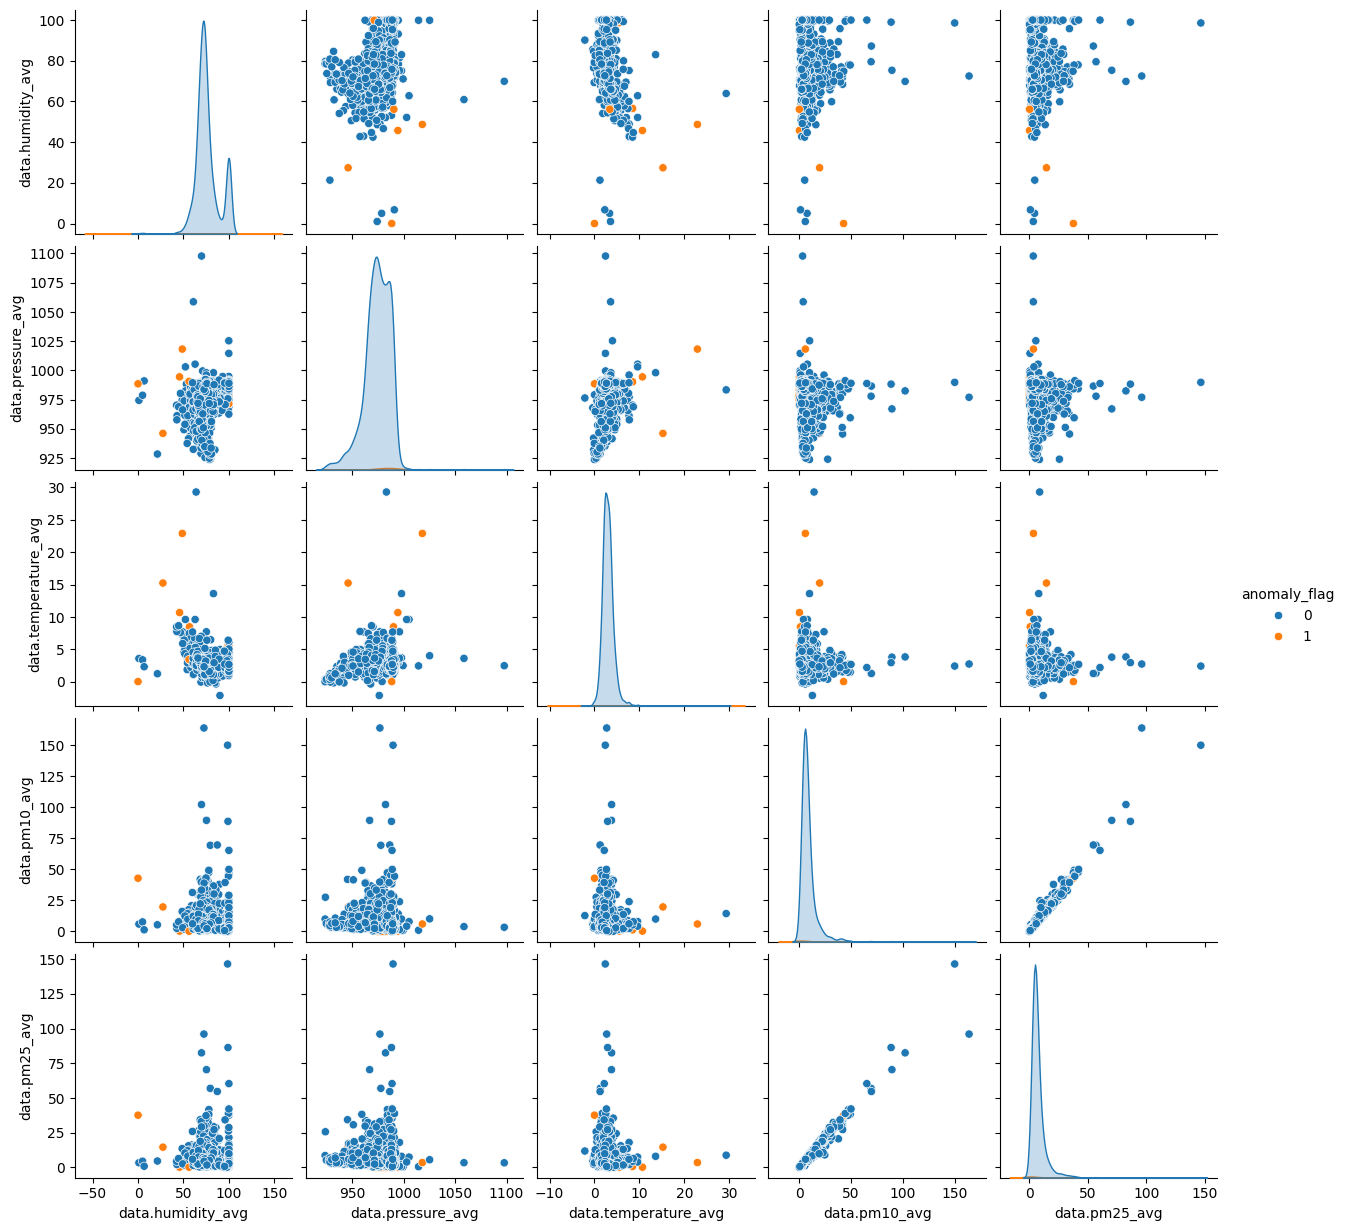

In [ ]:
df_plot = df_anomaly_pred[['data.humidity_avg',	'data.pressure_avg',	'data.temperature_avg',	'data.pm10_avg', 'data.pm25_avg','anomaly_flag']]
sns.pairplot(df_plot, hue='anomaly_flag')

## Zadanie przesortować dane tak aby na górze były największe anomalie

In [ ]:
df_anomaly_pred.sort_values(by='anomaly_score')

,timestamp,school.name,school.street,school.post_code,school.city,school.longitude,school.latitude,data.humidity_avg,data.pressure_avg,data.temperature_avg,data.pm10_avg,data.pm25_avg,data.pm10_avg_log,data.pm25_avg_log,anomaly_flag,anomaly_score
70,2024-11-21 14:04:25,SZKOŁA PODSTAWOWA NR 3 IM. JANA MATEJKI W PRUS...,MATEJKI,83-000,PRUSZCZ GDAŃSKI,18.636981,54.255547,45.733333,994.433333,10.666667,0.300000,0.173333,-1.171183,-1.696449,1,-0.748072
1151,2024-11-21 14:04:25,Technikum Informatyczne przy Noworudzkiej Szko...,Stara Droga,57-401,Nowa Ruda,16.51259,50.59164898,NaN,NaN,NaN,17.525000,10.550000,2.864199,2.357073,1,-0.733906
150,2024-11-21 14:04:25,"SZKOŁA PODSTAWOWA NR 2 IM. ""TKACZY ŚLĄSKICH"" W...",JELENIOGÓRSKA,58-400,KAMIENNA GÓRA,16.0229361940264,50.7839631113426,27.400000,946.083333,15.233333,19.750000,14.583333,2.983660,2.680565,1,-0.720345
1150,2024-11-21 14:04:25,Zespół Szkół Ogólnokształcących i Zawodowych i...,Komuny Paryskiej,59-700,Bolesławiec,15.563553,51.259736,NaN,NaN,NaN,7.525000,6.150000,2.019559,1.818077,1,-0.713718
24,2024-11-21 14:04:25,PRZEDSZKOLE NR 6 W BOCHNI,MUROWIANKA,32-700,BOCHNIA,20.4415,49.96533,98.533333,974.900000,2.900000,0.000000,0.000000,-4.605170,-4.605170,1,-0.689009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
780,2024-11-21 14:04:25,SZKOŁA PODSTAWOWA NR 2 IM. MARII SKŁODOWSKIEJ-...,UL. SKŁODOWSKIEJ,42-160,KRZEPICE,18.702433,50.964886,72.691667,970.650000,3.316667,6.466667,5.233333,1.868206,1.656957,0,-0.349142
222,2024-11-21 14:04:25,SZKOŁA PODSTAWOWA IM. WINCENTEGO WITOSA W GROM...,UL. WITOSA,33-180,GROMNIK,20.959304,49.840276,70.833333,972.441667,3.041667,5.008333,4.758333,1.613098,1.561997,0,-0.349068
837,2024-11-21 14:04:25,PUBLICZNA SZKOŁA PODSTAWOWA W KRZESZOWIE GÓRNYM,None,37-413,KRZESZÓW GÓRNY,22.384137,50.419185,71.983333,974.741667,3.075000,5.083333,4.708333,1.627932,1.551456,0,-0.348800
276,2024-11-21 14:04:25,I LICEUM OGÓLNOKSZTAŁCĄCE IM. JĘDRZEJA ŚNIADEC...,UL. STANISŁAWA MONIUSZKI,95-200,PABIANICE,19.32977177,51.65677453,71.211111,972.200000,2.933333,8.355556,6.811111,2.124123,1.920022,0,-0.348331
